In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
from google.colab import files
uploaded = files.upload()

Saving traffic_data.csv to traffic_data.csv


In [4]:
df = pd.read_csv('traffic_data.csv')
print(df.shape)
df.head()

(48120, 4)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [5]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [6]:
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df['Year'] = df['DateTime'].dt.year
df['Weekday'] = df['DateTime'].dt.weekday   # 0=Monday, 6=Sunday
df['IsWeekend'] = df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)
df.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month,Year,Weekday,IsWeekend
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,2015,6,1
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,2015,6,1
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,2015,6,1
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,2015,6,1
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,2015,6,1


In [7]:
df = df.drop(['ID', 'DateTime'], axis=1)
df.head()

,Junction,Vehicles,Hour,Day,Month,Year,Weekday,IsWeekend
0,1,15,0,1,11,2015,6,1
1,1,13,1,1,11,2015,6,1
2,1,10,2,1,11,2015,6,1
3,1,7,3,1,11,2015,6,1
4,1,9,4,1,11,2015,6,1


In [8]:
df.isnull().sum()

,0
Junction,0
Vehicles,0
Hour,0
Day,0
Month,0
Year,0
Weekday,0
IsWeekend,0


In [9]:
X = df.drop('Vehicles', axis=1)
y = df['Vehicles']
print(X.shape, y.shape)

(48120, 7) (48120,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(38496, 7) (9624, 7)


In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9690125872464426
MAE: 2.398708437240233
RMSE: 3.5537049920924697


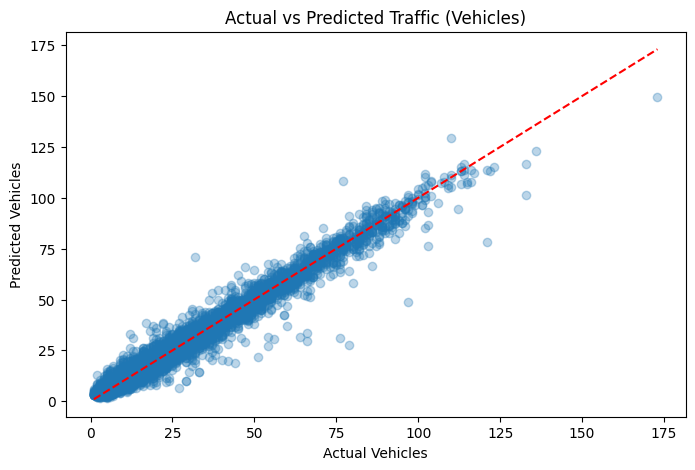

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Actual vs Predicted Traffic (Vehicles)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()